# Регрессия 

Лаборатная работа 2. Предсказание продолжительности поездки в такси на основе алгоритмов регрессии.

In [72]:
import pandas as pd

## Считваем предобработанные данные

In [73]:
data = pd.read_csv('../data/processed_trip_duration.csv')
data.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,in_nyc_center?,distance,hour_1,hour_2,...,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,hour_24,is_it_weekday?,is_it_first_vendor?(else 2nd)
0,1,-73.953918,40.778873,-73.963875,40.771164,400,1,1199.769914,1,0,...,0,0,0,0,0,0,0,0,1,0
1,2,-73.988312,40.731743,-73.994751,40.694931,1100,1,4123.945168,0,1,...,0,0,0,0,0,0,0,0,1,1
2,2,-73.997314,40.721458,-73.948029,40.774918,1635,1,7250.435807,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,-73.961670,40.759720,-73.956779,40.780628,1141,1,2358.286547,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2,-73.993614,40.751884,-73.995422,40.723862,1455,1,3115.641570,0,0,...,0,0,0,0,0,0,0,0,0,0


# Простая линейная регрессия

## Выделяем целевой признак и предиктор ()

In [74]:
y = data['trip_duration']
X = data[['distance']]

In [75]:
y

0          400
1         1100
2         1635
3         1141
4         1455
          ... 
655752     296
655753     315
655754     673
655755     447
655756    1224
Name: trip_duration, Length: 655757, dtype: int64

In [76]:
X

,distance
0,1199.769914
1,4123.945168
2,7250.435807
3,2358.286547
4,3115.641570
...,...
655752,1123.068070
655753,728.563489
655754,2295.919143
655755,846.721940


## Разделение данных на тренировочные и тестовые

In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [78]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge

## Масштабирование данных

In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [80]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## Обучение модели регрессии

In [81]:
lr = LinearRegression().fit(X_train, y_train)

In [82]:
y_pred = lr.predict(X_test)

In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt

### Метрики качества

In [84]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
print(f'R^2: {r2_score(y_test, y_pred)}')

MAE: 248.2854731761653
MSE: 112953.3065161714
RMSE: 336.085266734755
MAPE: 0.6865332346327039
R^2: 0.5097791281955069


### Визуализация результатов

In [85]:
import matplotlib.pyplot as plt

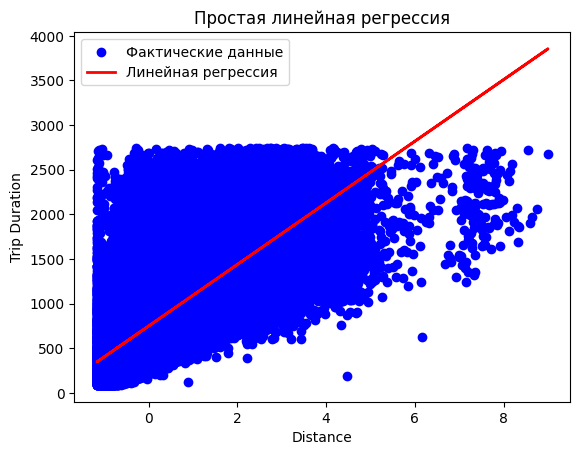

In [86]:
import matplotlib.pyplot as plt

plt.scatter(X_test, y_test, color="blue", label="Фактические данные")  # Точки реальных данных
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Линейная регрессия")  # Линия предсказаний
plt.xlabel("Distance")
plt.ylabel("Trip Duration")
plt.title("Простая линейная регрессия")
plt.legend()
plt.show()

# Регрессия с регуляризацией

## Ridge

## Lasso

## Elastic Net

## Полиномиальная регрессия

### Реализация пайплайна

In [87]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler